In [ ]:
import torch
from tqdm import tqdm
from scipy.ndimage.filters import gaussian_filter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import pyplot as plt
import torch
from torch.utils.data.sampler import Sampler
from torchvision import transforms
from PIL import Image
import time
from IPython.display import clear_output
from einops import rearrange
from affex.data.utils import BatchKeys
from affex.utils.torch import to_device
from affex.utils.utils import ResultDict
from affex.utils.grid import create_experiment, load_yaml
from affex.models import build_model_preconfigured
from affex.data import get_dataloaders
from affex.data.utils import min_max_scale


import copy
import torch.nn.functional as F
import saliency.core as saliency


import lovely_tensors as lt
lt.monkey_patch()


In [14]:
parameters = load_yaml("parameters/pascal/cut_iauc_miou_N1K1.yaml")
grid_name = parameters["grid"]

runs_parameters = create_experiment(parameters)
parameters = runs_parameters[0]  # Take the first set of parameters


Initial runs: 20
Read excluded runs: 0
Remaining runs: 20


In [21]:
device = "cuda"
n_ways = parameters.get("n_ways", 1)

model, image_size = build_model_preconfigured(model_name=parameters["model"])
model.eval()
model.to(device)
log_frequency = parameters.get("log_frequency", 50)

for k in parameters["dataset"]["datasets"]:
    parameters["dataset"]["datasets"][k]["image_size"] = image_size

if "preprocess" not in parameters["dataset"]:
    parameters["dataset"]["preprocess"] = {} 
parameters["dataset"]["preprocess"]["image_size"] = image_size

_, val, _ = get_dataloaders(
    copy.deepcopy(parameters["dataset"]),
    copy.deepcopy(parameters["dataloader"]),
    num_processes=1,
    )
data = val['val_pascal5i_N1K1']

WARNING [10-13 15:31:29] [pascal] load_embeddings is not specified. Assuming load_embeddings=False.


Using pe from state_dict
Loading image filenames from val...


Loading annotations...: 100%|██████████| 1449/1449 [00:01<00:00, 1066.46it/s]


In [134]:
batch = next(iter(data))

In [135]:
from affex.substitution import Substitutor


batch, dataset_name  = batch

substitutor = Substitutor(substitute=False)
substitutor.reset(batch=batch)
batch = next(substitutor)

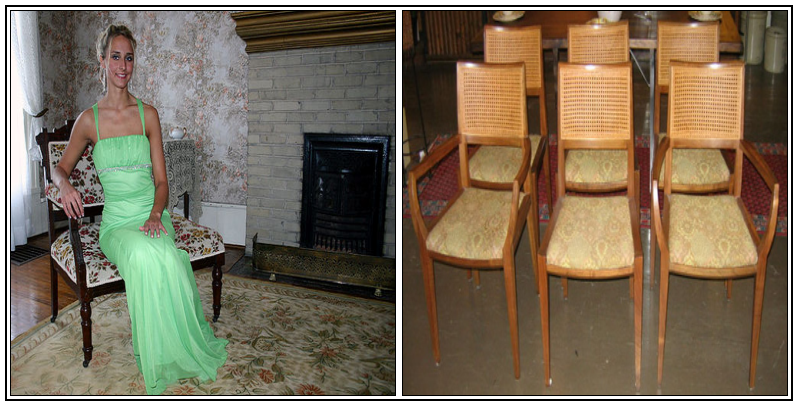

In [136]:
from affex.data.utils import BatchKeys
from affex.utils.segmentation import unnormalize

input_dict, gt = batch
unnormalize(input_dict[BatchKeys.IMAGES]).rgb

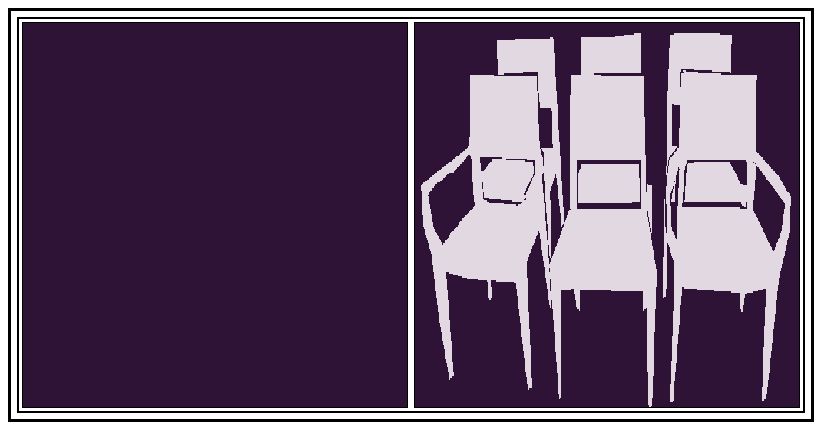

In [137]:
input_dict[BatchKeys.PROMPT_MASKS].chans

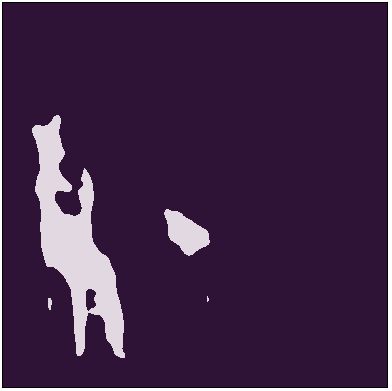

In [138]:
from affex.utils.utils import ResultDict

import torch.nn.functional as F

input_dict = to_device(input_dict, device)
target_shape = input_dict[BatchKeys.IMAGES][:, 0].shape[2:]

with torch.no_grad():
    result = model(input_dict, postprocess=False)

logits = F.interpolate(
            result[ResultDict.LOGITS],
            size=target_shape,
            mode="bilinear",
            align_corners=False,
            antialias=False,
        ).argmax(dim=1)
explanation_mask = F.one_hot(logits, num_classes=n_ways+1).permute(0, 3, 1, 2)[0].bool()[1]
logits.chans

In [140]:
class_idx_str = 'class_idx_str'
call_model_args = {class_idx_str: 1}

images = input_dict[BatchKeys.IMAGES].detach().cpu()

def call_model_function(images, call_model_args=None, expected_keys=None):
    images = torch.tensor(images, device=device, dtype=torch.float32)
    images.requires_grad = True
    
    input_dict[BatchKeys.IMAGES] = images
    target_class_idx =  call_model_args[class_idx_str]
    output = model(input_dict, postprocess=False)[ResultDict.LOGITS]
    m = torch.nn.Softmax(dim=1)
    output = m(output)
    if saliency.base.INPUT_OUTPUT_GRADIENTS in expected_keys:
        outputs = output[:,target_class_idx,explanation_mask].mean()
        grads = torch.autograd.grad(outputs, images, grad_outputs=torch.ones_like(outputs))
        # grads = torch.movedim(grads[0], 1, 3)
        grads = grads[0]
        gradients = grads.cpu().detach().numpy()
        return {saliency.base.INPUT_OUTPUT_GRADIENTS: gradients}
    else:
        raise ValueError(f"Expected keys {expected_keys} not supported")
        one_hot = torch.zeros_like(output)
        one_hot[:,target_class_idx] = 1
        model.zero_grad()
        output.backward(gradient=one_hot, retain_graph=True)
        return conv_layer_outputs

In [124]:
# Construct the saliency object. This alone doesn't do anthing.
gradient_saliency = saliency.GradientSaliency()

# Compute the vanilla mask and the smoothed mask.
vanilla_mask_3d = gradient_saliency.GetMask(images[0].cpu(), call_model_function, call_model_args)
vanilla_mask = torch.tensor(vanilla_mask_3d).mean(dim=1)

In [125]:
def min_max_scale(tensor, quantile=None):
    if quantile is None:
        tmax = tensor.max()
    else:
        tmax = torch.quantile(tensor, quantile)
    tmin = tensor.min()
    return ((tensor - tmin) / (tmax - tmin)).clamp(0, 1)


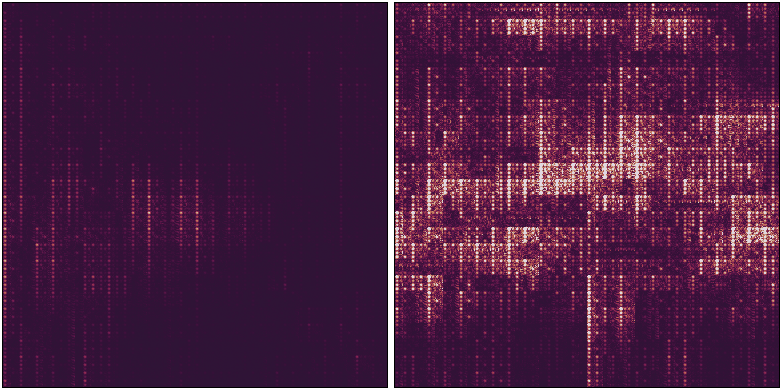

In [126]:
image_2d = torch.sum(torch.abs(torch.tensor(vanilla_mask_3d)), axis=1)

vmax = torch.quantile(image_2d, 0.99)
vmin = torch.min(image_2d)

torch.clip((image_2d - vmin) / (vmax - vmin), 0, 1).chans


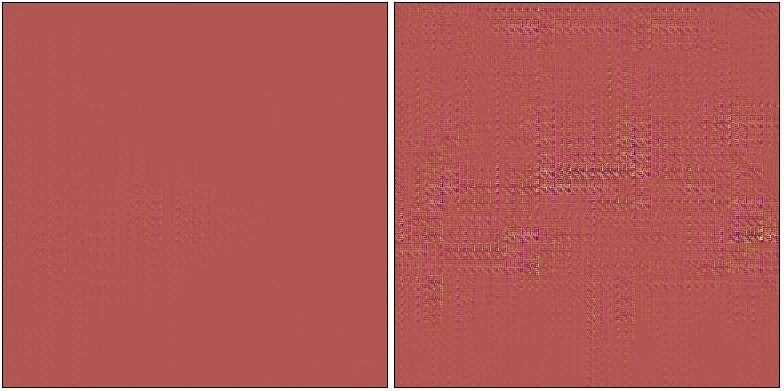

In [128]:
min_max_scale(torch.mean(torch.tensor(vanilla_mask_3d), axis=1)).chans

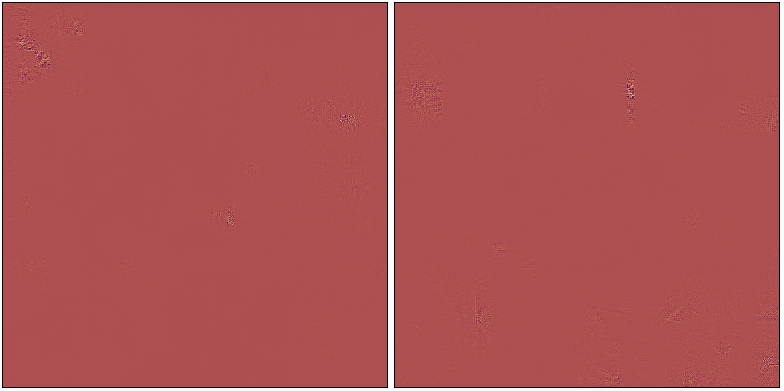

In [82]:
min_max_scale(vanilla_mask).chans

In [145]:
# Construct the saliency object. This doesn't yet compute the saliency mask, it just sets up the necessary ops.
integrated_gradients = saliency.IntegratedGradients()
guided_ig = saliency.GuidedIG()

# Baseline is a black image for vanilla integrated gradients.
baseline = np.zeros(images[0].shape)

# Compute the vanilla mask and the Guided IG mask.
vanilla_integrated_gradients_mask_3d = integrated_gradients.GetMask(
  images[0].cpu().numpy(), call_model_function, call_model_args, x_steps=25, x_baseline=baseline, batch_size=1)
guided_ig_mask_3d = guided_ig.GetMask(
  images[0].cpu().numpy(), call_model_function, call_model_args, x_steps=25, x_baseline=baseline, max_dist=1.0, fraction=0.5)

In [146]:
torch.tensor(vanilla_integrated_gradients_mask_3d)

tensor[2, 3, 384, 384] f64 n=884736 (6.8Mb) x∈[-1.493, 1.184] μ=-4.587e-06 σ=0.020

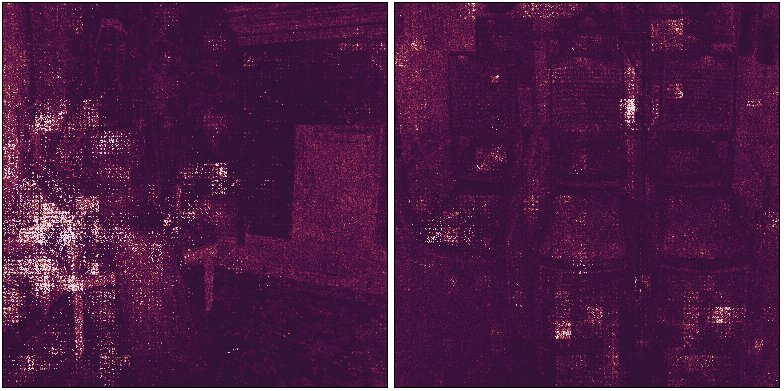

In [ ]:
min_max_scale(torch.sum(torch.abs(torch.tensor(guided_ig_mask_3d)), axis=1), quantile=0.99).chans

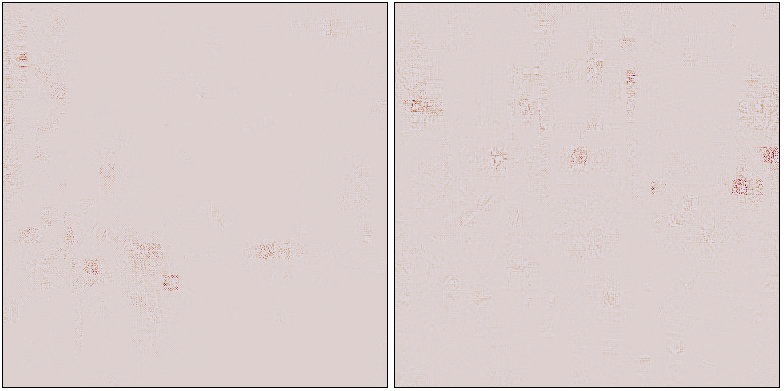

In [152]:
min_max_scale(torch.mean((torch.tensor(vanilla_integrated_gradients_mask_3d)), axis=1), quantile=0.99).chans

In [157]:
torch.sort(min_max_scale(torch.sum(torch.abs(torch.tensor(guided_ig_mask_3d)), axis=1), quantile=0.99).flatten(), descending=True).indices.p

tensor([ 37305, 185324, 185325,  ...,  16768, 113587, 103874])

In [158]:
torch.sort(min_max_scale(torch.sum(torch.abs(torch.tensor(guided_ig_mask_3d)), axis=1)).flatten(), descending=True).indices.p

tensor([ 91070,  86450,  86838,  ...,  16768, 113587, 103874])